# **Step 1: Setup & Data Loading for SVHN**

## Explanation

- **Random Seed & Transformation:**
  - Set the random seed for reproducibility.
  - Define the data transformation for SVHN (32×32 color images).
- **Dataset Loading:**
  - Load both the training and test splits from the SVHN dataset.
  - Wrap the dataset with a custom class to correct labels (SVHN uses the label “10” for digit 0).
- **Dataset Combination & Splitting:**
  - Combine the training and test splits using `ConcatDataset`.
  - Split the combined dataset into:
    - Training set: 70%
    - Validation set: 10%
    - Test set: 20%
- **Helper Functions:**
  - Display two sample images per class (using color images).
  - Plot the class distribution.


100%|██████████| 182M/182M [00:18<00:00, 9.79MB/s]
100%|██████████| 64.3M/64.3M [00:22<00:00, 2.80MB/s]


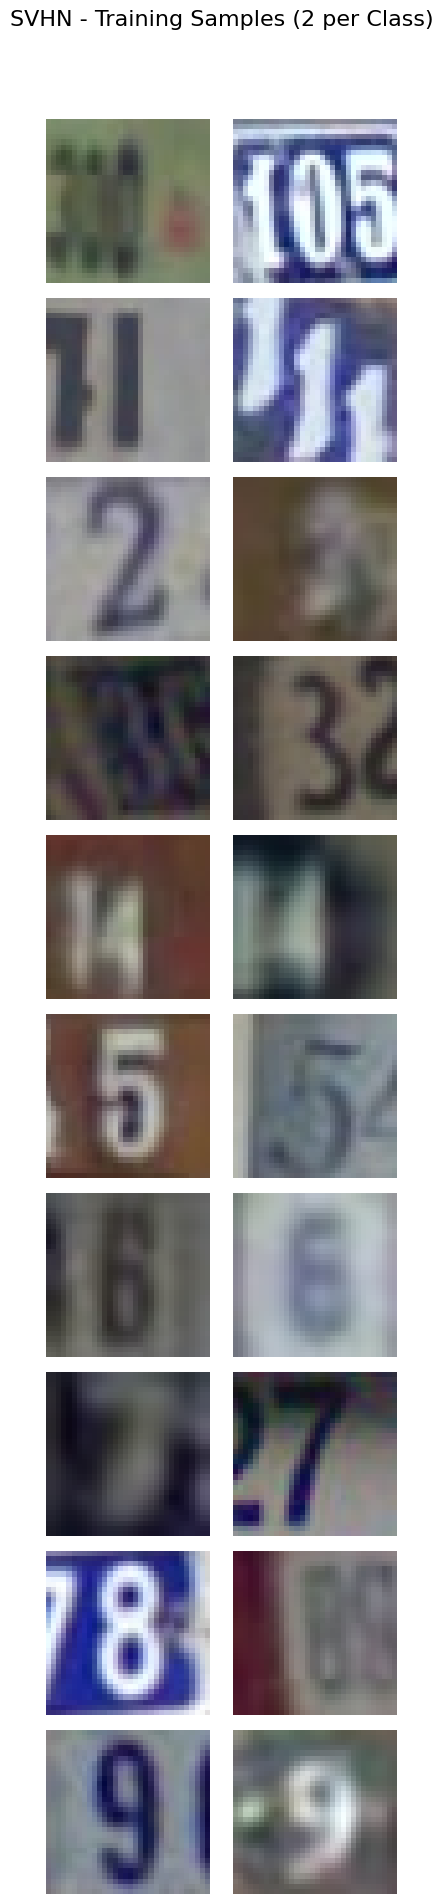

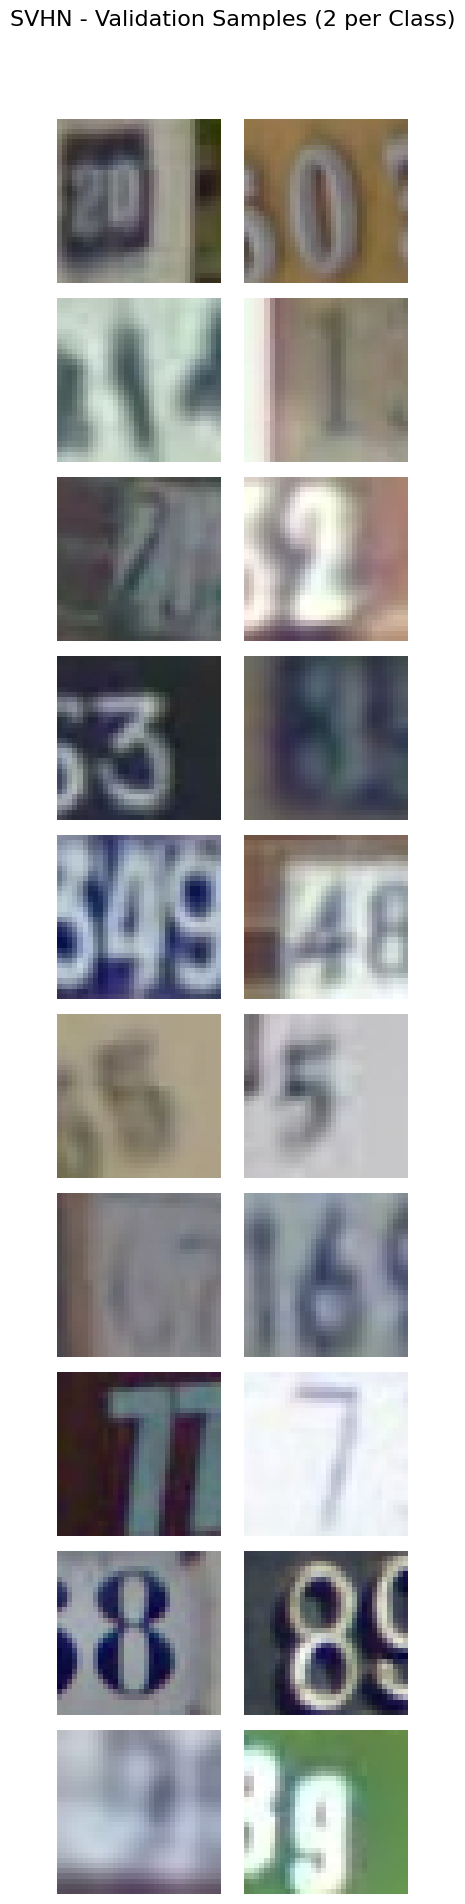

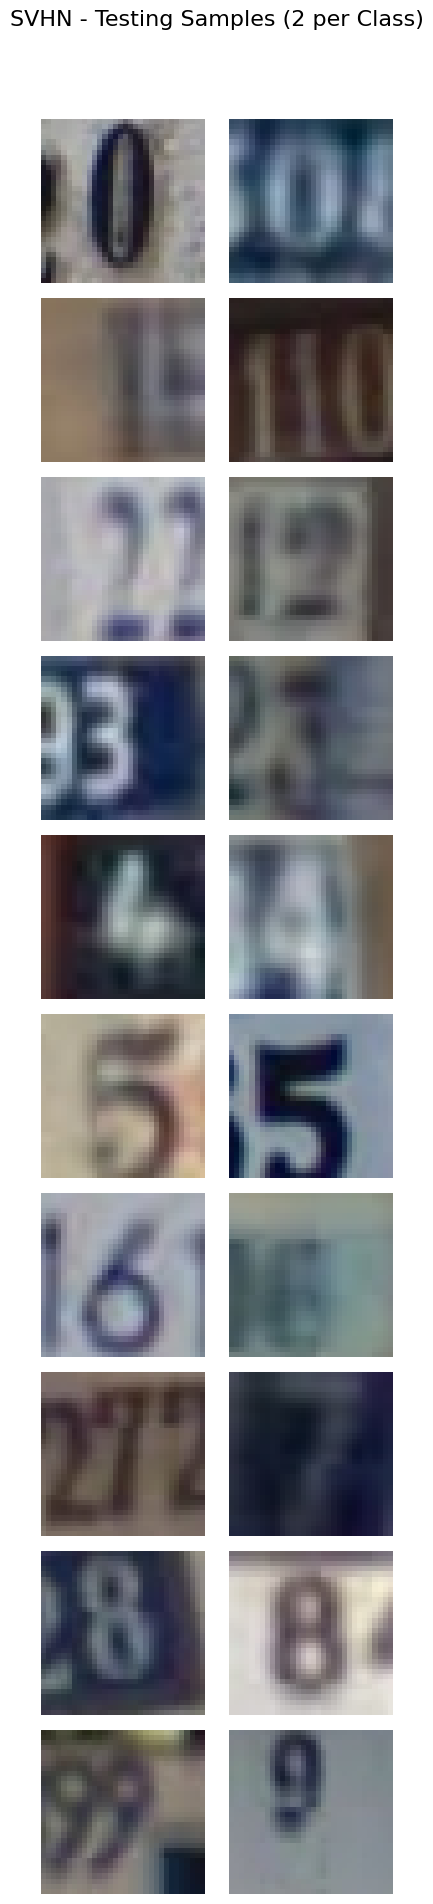

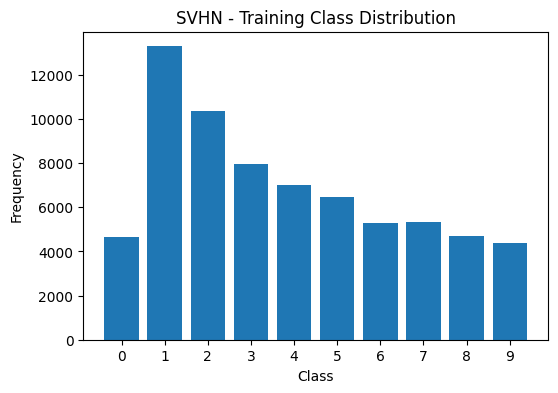

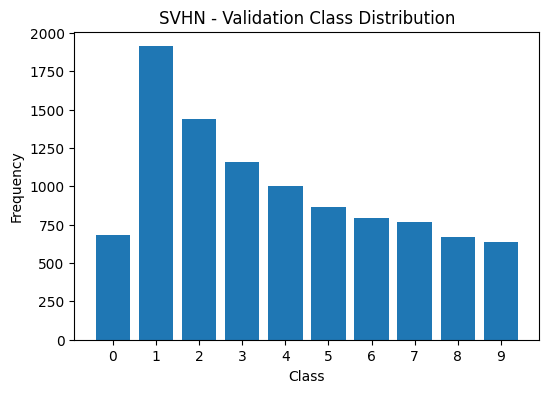

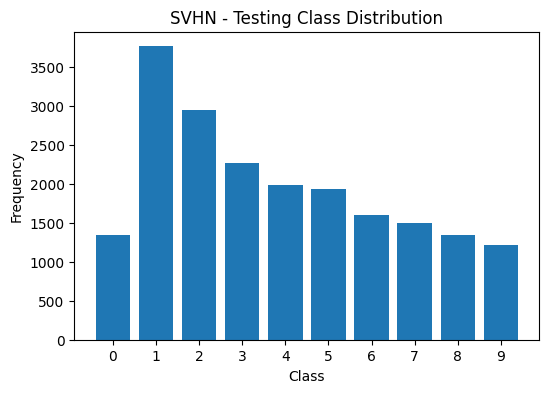

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset, random_split

# -------------------------------
# Set Seed for Reproducibility
# -------------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# -------------------------------
# Define Data Transform for SVHN (color images)
# -------------------------------
svhn_transform = transforms.ToTensor()  # SVHN images are in [0,1] RGB format

# -------------------------------
# Load and Combine SVHN Dataset with Label Adjustment
# -------------------------------
# Load the SVHN training and test splits.
svhn_train = torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=svhn_transform)
svhn_test  = torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=svhn_transform)

# SVHN uses the label '10' to represent digit '0'. We wrap the dataset to fix this.
class SVHNWrapper(torch.utils.data.Dataset):
    def __init__(self, svhn_dataset):
        self.svhn_dataset = svhn_dataset
    def __len__(self):
        return len(self.svhn_dataset)
    def __getitem__(self, index):
        img, label = self.svhn_dataset[index]
        label = 0 if label == 10 else label  # Adjust label: 10 -> 0
        return img, label

svhn_train = SVHNWrapper(svhn_train)
svhn_test  = SVHNWrapper(svhn_test)

# Combine the training and test splits.
svhn_full = ConcatDataset([svhn_train, svhn_test])

# -------------------------------
# Split Dataset into Train (70%), Val (10%), and Test (20%)
# -------------------------------
def split_dataset(dataset, train_ratio=0.7, val_ratio=0.1, test_ratio=0.2):
    total_len = len(dataset)
    train_len = int(train_ratio * total_len)
    val_len   = int(val_ratio * total_len)
    test_len  = total_len - train_len - val_len
    return random_split(dataset, [train_len, val_len, test_len])

svhn_train_split, svhn_val_split, svhn_test_split = split_dataset(svhn_full)

# -------------------------------
# Helper Functions for Plotting Samples & Distributions
# -------------------------------
def get_samples_per_class(dataset_split, num_samples=2):
    samples = {i: [] for i in range(10)}
    for img, label in dataset_split:
        if len(samples[label]) < num_samples:
            samples[label].append(img)
        if all(len(samples[c]) == num_samples for c in range(10)):
            break
    return samples

def plot_samples(samples, dataset_name, split_name):
    # For SVHN, images are RGB so we use permute to rearrange dimensions.
    fig, axes = plt.subplots(10, 2, figsize=(4, 20))
    fig.suptitle(f'{dataset_name} - {split_name} Samples (2 per Class)', fontsize=16)
    for cls in range(10):
        for i in range(2):
            ax = axes[cls, i]
            img = samples[cls][i]
            ax.imshow(img.permute(1, 2, 0))  # Convert CxHxW to HxWxC for display
            ax.axis('off')
            if i == 0:
                ax.set_ylabel(f'Class {cls}', fontsize=12)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_distribution(dataset_split, dataset_name, split_name):
    counts = {i: 0 for i in range(10)}
    for _, label in dataset_split:
        counts[label] += 1
    classes = list(counts.keys())
    frequencies = list(counts.values())
    plt.figure(figsize=(6, 4))
    plt.bar(classes, frequencies, tick_label=classes)
    plt.xlabel('Class')
    plt.ylabel('Frequency')
    plt.title(f'{dataset_name} - {split_name} Class Distribution')
    plt.show()

# -------------------------------
# Plot Sample Images and Class Distributions for Each Split
# -------------------------------
svhn_train_samples = get_samples_per_class(svhn_train_split)
svhn_val_samples   = get_samples_per_class(svhn_val_split)
svhn_test_samples  = get_samples_per_class(svhn_test_split)

plot_samples(svhn_train_samples, 'SVHN', 'Training')
plot_samples(svhn_val_samples, 'SVHN', 'Validation')
plot_samples(svhn_test_samples, 'SVHN', 'Testing')

plot_distribution(svhn_train_split, 'SVHN', 'Training')
plot_distribution(svhn_val_split, 'SVHN', 'Validation')
plot_distribution(svhn_test_split, 'SVHN', 'Testing')

# **Step 2: Define the CNN Model for SVHN**

## Explanation

For SVHN, we define a CNN model similar to the MNIST version but modified for 32×32 color images (3 channels). This model includes:

- **Convolutional Layers:** Two convolutional layers, each followed by:
  - Batch normalization
  - ReLU activations
- **Pooling:** Max pooling layers to reduce spatial dimensions.
- **Fully Connected Layer:** A final fully connected layer that outputs logits for 10 classes.


In [2]:
import torch.nn as nn

class SimpleCNN_SVHN(nn.Module):
    def __init__(self, in_channels, img_size):
        """
        in_channels: Number of channels in the input image (3 for SVHN).
        img_size: Height/width of the square input image (32 for SVHN).
        """
        super(SimpleCNN_SVHN, self).__init__()
        # First convolutional block: Conv -> BatchNorm -> ReLU -> MaxPool
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Second convolutional block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        # After two poolings, the image size is reduced by a factor of 4.
        final_size = img_size // 4
        # Fully connected layer for classification (10 classes)
        self.fc = nn.Linear(64 * final_size * final_size, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)  # Flatten the tensor
        x = self.fc(x)             # Output raw logits
        return x


# **Step 3: Define Training and Evaluation Functions for SVHN**

## Explanation

We now re-use (or slightly adapt) our training and evaluation functions from the MNIST pipeline. These functions will:

- Train the model for one epoch.
- Compute evaluation metrics including loss, accuracy, precision, and recall.
- Plot training curves to monitor performance.

They work for both datasets, with the only modification being that our SVHN model handles 3-channel images.


In [3]:
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall

def plot_training_curves(epochs_range, train_losses, val_losses, train_accs, val_accs, dataset_name):
    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label="Train Loss")
    plt.plot(epochs_range, val_losses, label="Validation Loss")
    plt.title(f"{dataset_name} Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, label="Train Accuracy")
    plt.plot(epochs_range, val_accs, label="Validation Accuracy")
    plt.title(f"{dataset_name} Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()


#** Step 4: Hyperparameter Tuning & Final Model Training for SVHN**

## Explanation

This section performs a grid search over hyperparameters using early stopping. The hyperparameters being tuned include:

- Batch size
- Optimizer
- Learning rate
- Activation function

We track the configuration that results in the lowest validation loss. Once the optimal configuration is determined, we reinitialize and train a final SVHN model using that configuration and evaluate its performance on the SVHN test set.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Tuning: Batch Size=64, Optimizer=Adam, LR=0.001, Activation=ReLU
Epoch 1/50 - Train Loss: 0.7910, Train Acc: 0.7635 | Val Loss: 0.6327, Val Acc: 0.8090
Epoch 2/50 - Train Loss: 0.5083, Train Acc: 0.8565 | Val Loss: 0.5433, Val Acc: 0.8462
Epoch 3/50 - Train Loss: 0.4420, Train Acc: 0.8746 | Val Loss: 0.5059, Val Acc: 0.8521
Epoch 4/50 - Train Loss: 0.3989, Train Acc: 0.8864 | Val Loss: 0.4325, Val Acc: 0.8731
Epoch 5/50 - Train Loss: 0.3647, Train Acc: 0.8958 | Val Loss: 0.4004, Val Acc: 0.8865
Epoch 6/50 - Train Loss: 0.3390, Train Acc: 0.9026 | Val Loss: 0.4176, Val Acc: 0.8783
Epoch 7/50 - Train Loss: 0.3125, Train Acc: 0.9104 | Val Loss: 0.3953, Val Acc: 0.8901
Epoch 8/50 - Train Loss: 0.2924, Train Acc: 0.9165 | Val Loss: 0.4156, Val Acc: 0.8811
Epoch 9/50 - Train Loss: 0.2774, Train Acc: 0.9198 | Val Loss: 0.4104, Val Acc: 0.8812
Epoch 10/50 - Train Loss: 0.2611, Train Acc: 0.9239 | Val Loss: 0.4046, Val Acc: 0.8870
Epoch 11/50 - Train Loss: 0.2484, Train Acc: 0.9292 | Val Loss:

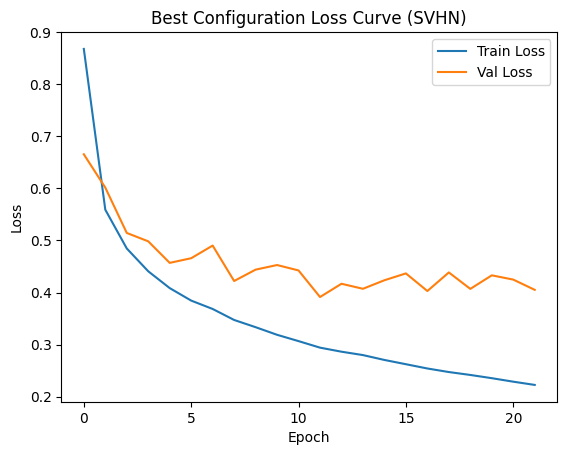

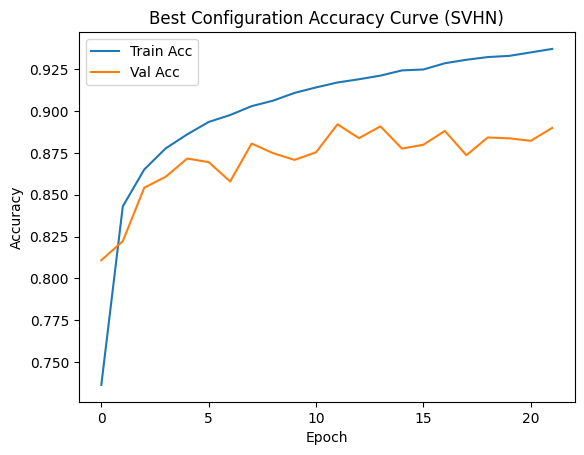


Training Final SVHN Model with Best Hyperparameters...
Epoch 1/50 - Train Loss: 0.8619, Train Acc: 0.7375 | Val Loss: 0.6036, Val Acc: 0.8293
Epoch 2/50 - Train Loss: 0.5538, Train Acc: 0.8425 | Val Loss: 0.5517, Val Acc: 0.8415
Epoch 3/50 - Train Loss: 0.4847, Train Acc: 0.8636 | Val Loss: 0.5239, Val Acc: 0.8466
Epoch 4/50 - Train Loss: 0.4459, Train Acc: 0.8737 | Val Loss: 0.4858, Val Acc: 0.8615
Epoch 5/50 - Train Loss: 0.4131, Train Acc: 0.8832 | Val Loss: 0.5141, Val Acc: 0.8504
Epoch 6/50 - Train Loss: 0.3922, Train Acc: 0.8904 | Val Loss: 0.4860, Val Acc: 0.8630
Epoch 7/50 - Train Loss: 0.3724, Train Acc: 0.8953 | Val Loss: 0.4680, Val Acc: 0.8615
Epoch 8/50 - Train Loss: 0.3558, Train Acc: 0.8999 | Val Loss: 0.4564, Val Acc: 0.8705
Epoch 9/50 - Train Loss: 0.3408, Train Acc: 0.9040 | Val Loss: 0.4290, Val Acc: 0.8805
Epoch 10/50 - Train Loss: 0.3271, Train Acc: 0.9079 | Val Loss: 0.4174, Val Acc: 0.8825
Epoch 11/50 - Train Loss: 0.3153, Train Acc: 0.9112 | Val Loss: 0.4586, V

In [6]:
import os
import torch.optim as optim
import matplotlib.pyplot as plt

# Create directories for outputs (optional)
os.makedirs("svhn_output_plots", exist_ok=True)
os.makedirs("svhn_output_metrics", exist_ok=True)

# Define an improved CNN model for SVHN with customizable activation function.
class SimpleCNN_SVHN_Improved(nn.Module):
    def __init__(self, in_channels, img_size, activation=nn.ReLU()):
        super(SimpleCNN_SVHN_Improved, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        final_size = img_size // 4  # For SVHN: 32//4 = 8
        self.fc    = nn.Linear(64 * final_size * final_size, 10)

    def forward(self, x):
        x = self.pool(self.activation(self.bn1(self.conv1(x))))
        x = self.pool(self.activation(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# Early stopping training function (same as before).
def train_with_early_stopping(model, train_loader, val_loader, criterion, optimizer, device, epochs=50, patience=10):
    best_val_loss = float('inf')
    best_epoch = 0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_model_state = None

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * images.size(0)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch}/50 - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_model_state = model.state_dict()
        elif epoch - best_epoch >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    return model, train_losses, train_accs, val_losses, val_accs, best_val_loss

# Define hyperparameter grid for SVHN.
optimizers_to_try = ["Adam", "SGD"]
learning_rates = [0.001, 0.005, 0.0005]
activations = {"ReLU": nn.ReLU(), "LeakyReLU": nn.LeakyReLU(0.1)}
batch_sizes = [64, 128]

best_config = None
best_val_loss_overall = float('inf')
best_tuning_results = None
results = []

for bs in batch_sizes:
    train_loader = DataLoader(svhn_train_split, batch_size=bs, shuffle=True)
    val_loader = DataLoader(svhn_val_split, batch_size=bs, shuffle=False)

    for opt_name in optimizers_to_try:
        for lr in learning_rates:
            for act_name, act_fn in activations.items():
                print(f"\nTuning: Batch Size={bs}, Optimizer={opt_name}, LR={lr}, Activation={act_name}")
                model = SimpleCNN_SVHN_Improved(in_channels=3, img_size=32, activation=act_fn).to(device)
                if opt_name == "Adam":
                    optimizer = optim.Adam(model.parameters(), lr=lr)
                elif opt_name == "SGD":
                    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
                criterion = torch.nn.CrossEntropyLoss()

                trained_model, train_losses, train_accs, val_losses, val_accs, final_val_loss = train_with_early_stopping(
                    model, train_loader, val_loader, criterion, optimizer, device, epochs=50, patience=10
                )

                result = {
                    "batch_size": bs,
                    "optimizer": opt_name,
                    "learning_rate": lr,
                    "activation": act_name,
                    "val_loss": final_val_loss,
                    "val_accuracy": val_accs[-1]
                }
                results.append(result)

                if final_val_loss < best_val_loss_overall:
                    best_val_loss_overall = final_val_loss
                    best_config = result
                    best_tuning_results = {
                        "model_state": trained_model.state_dict(),
                        "train_losses": train_losses,
                        "train_accs": train_accs,
                        "val_losses": val_losses,
                        "val_accs": val_accs
                    }

print("\nBest Hyperparameter Configuration for SVHN:")
print(best_config)

plt.figure()
plt.plot(best_tuning_results["train_losses"], label="Train Loss")
plt.plot(best_tuning_results["val_losses"], label="Val Loss")
plt.title("Best Configuration Loss Curve (SVHN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(best_tuning_results["train_accs"], label="Train Acc")
plt.plot(best_tuning_results["val_accs"], label="Val Acc")
plt.title("Best Configuration Accuracy Curve (SVHN)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Final model training using the best configuration.
best_bs = best_config["batch_size"]
final_train_loader = DataLoader(svhn_train_split, batch_size=best_bs, shuffle=True)
final_val_loader = DataLoader(svhn_val_split, batch_size=best_bs, shuffle=False)

final_model_svhn = SimpleCNN_SVHN_Improved(in_channels=3, img_size=32, activation=activations[best_config["activation"]]).to(device)
if best_config["optimizer"] == "Adam":
    final_optimizer = optim.Adam(final_model_svhn.parameters(), lr=best_config["learning_rate"])
elif best_config["optimizer"] == "SGD":
    final_optimizer = optim.SGD(final_model_svhn.parameters(), lr=best_config["learning_rate"], momentum=0.9)
criterion = torch.nn.CrossEntropyLoss()

print("\nTraining Final SVHN Model with Best Hyperparameters...")
final_model_svhn, final_train_losses, final_train_accs, final_val_losses, final_val_accs, _ = train_with_early_stopping(
    final_model_svhn, final_train_loader, final_val_loader, criterion, final_optimizer, device, epochs=50, patience=10
)

final_test_loader = DataLoader(svhn_test_split, batch_size=best_bs, shuffle=False)
final_test_loss, final_test_acc, final_test_prec, final_test_rec = evaluate(final_model_svhn, final_test_loader, criterion, device)
print("\nFinal SVHN Model Test Metrics:")
print(f"Loss: {final_test_loss:.4f}, Accuracy: {final_test_acc:.4f}, Precision: {final_test_prec:.4f}, Recall: {final_test_rec:.4f}")

# **Step 5: Model Evaluation and Visualization for SVHN**

## Explanation

This section evaluates the final SVHN model on the SVHN test set. The evaluation includes:

- **Misclassified Examples Visualization:** Display RGB images of misclassified test samples.
- **Softmax Probability Bar Charts:** Present softmax probability bar charts for selected test samples.
- **Confusion Matrix:** Plot a confusion matrix to assess per-class performance.
- **Classification Report:** Print a detailed classification report summarizing per-class performance.


SVHN Misclassifications:


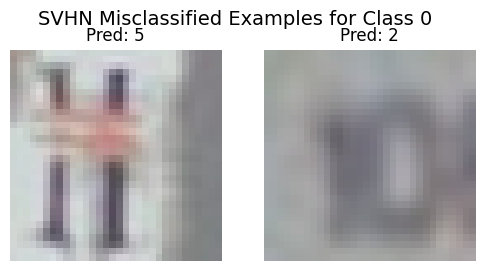

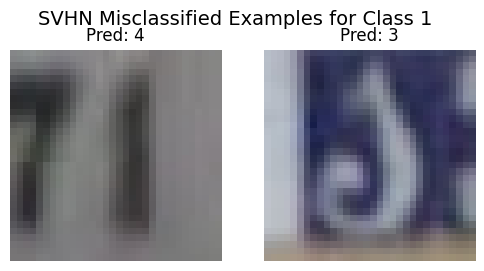

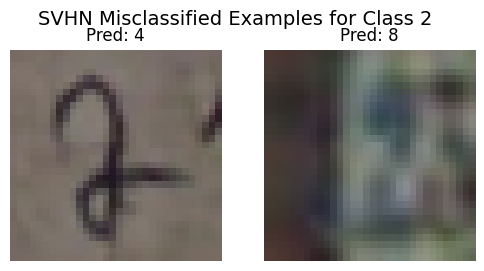

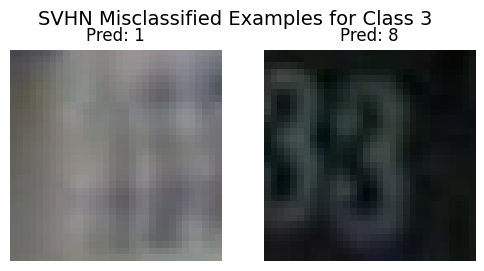

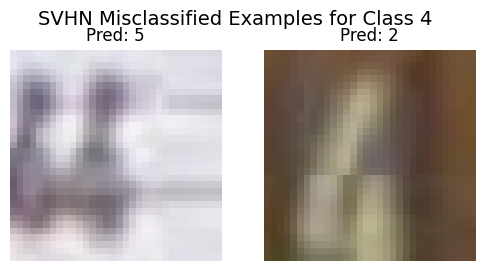

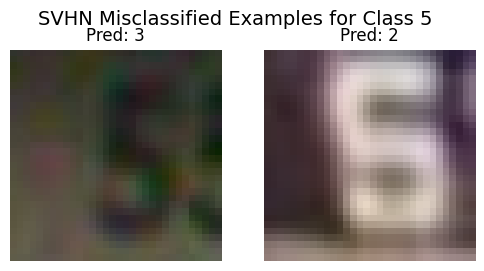

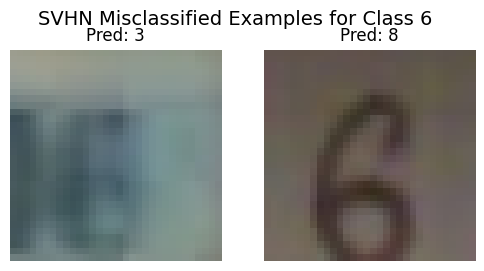

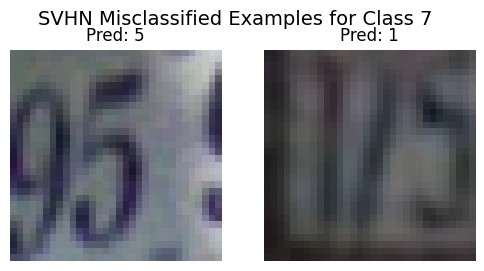

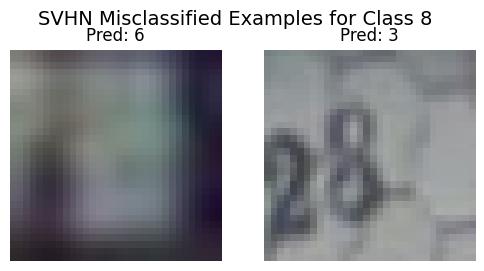

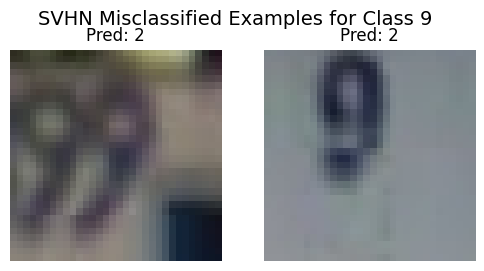


SVHN Inference and Visualization:


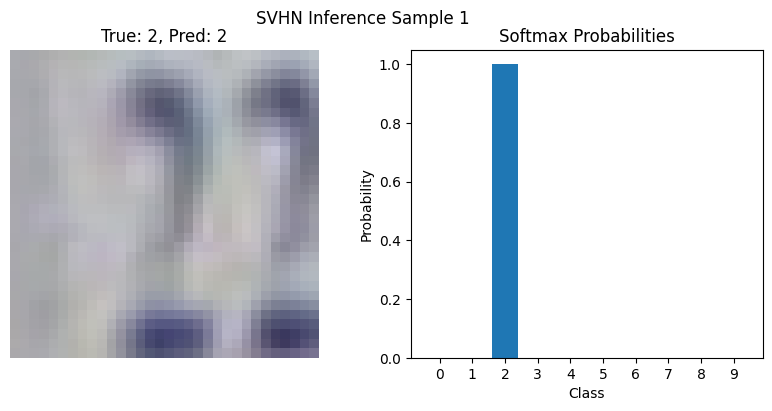

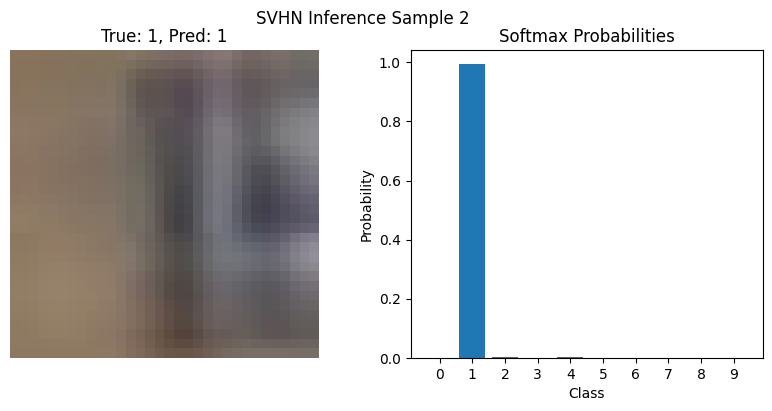

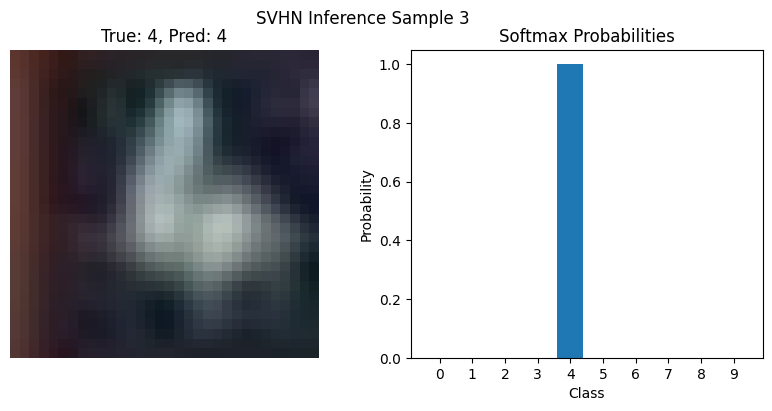

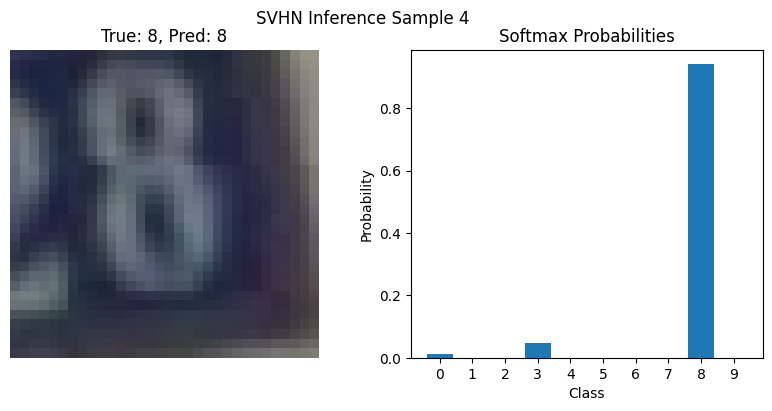

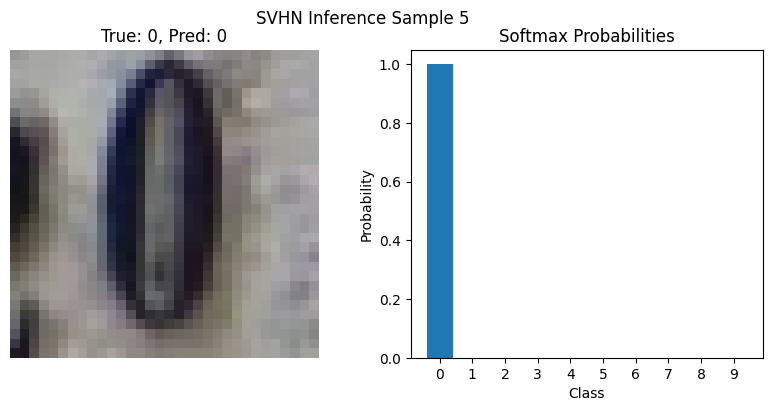

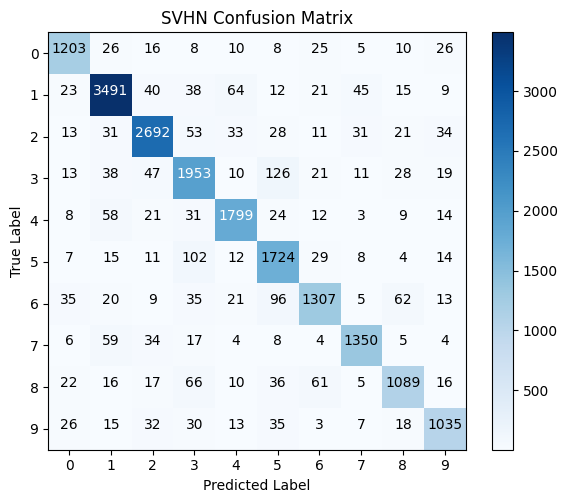

Classification Report for SVHN
              precision    recall  f1-score   support

           0     0.8872    0.8998    0.8934      1337
           1     0.9262    0.9290    0.9276      3758
           2     0.9222    0.9135    0.9178      2947
           3     0.8371    0.8619    0.8493      2266
           4     0.9104    0.9090    0.9097      1979
           5     0.8221    0.8951    0.8571      1926
           6     0.8748    0.8153    0.8440      1603
           7     0.9184    0.9054    0.9119      1491
           8     0.8636    0.8139    0.8380      1338
           9     0.8742    0.8526    0.8632      1214

    accuracy                         0.8884     19859
   macro avg     0.8836    0.8795    0.8812     19859
weighted avg     0.8890    0.8884    0.8884     19859



In [7]:
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report

def visualize_misclassifications_svhn(model, test_loader, device, dataset_name):
    model.eval()
    misclassified = {i: [] for i in range(10)}
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            for img, true_label, pred_label in zip(images, labels, preds):
                if true_label.item() != pred_label.item():
                    if len(misclassified[true_label.item()]) < 2:
                        misclassified[true_label.item()].append((img.cpu(), pred_label.item()))
            if all(len(misclassified[i]) >= 2 for i in range(10)):
                break

    for cls in range(10):
        examples = misclassified[cls]
        if examples:
            fig, axes = plt.subplots(1, len(examples), figsize=(3 * len(examples), 3))
            fig.suptitle(f'{dataset_name} Misclassified Examples for Class {cls}', fontsize=14)
            if len(examples) == 1:
                axes = [axes]
            for ax, (img, pred_label) in zip(axes, examples):
                # For SVHN, display RGB image.
                ax.imshow(img.permute(1, 2, 0))
                ax.set_title(f"Pred: {pred_label}")
                ax.axis('off')
            plt.show()
        else:
            print(f"No misclassified examples found for class {cls} in {dataset_name}.")

def inference_and_visualization_svhn(model, test_loader, device, dataset_name, num_samples=5):
    model.eval()
    softmax = F.softmax
    images_list = []
    true_labels_list = []
    preds_list = []
    probs_list = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probabilities = softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            for i in range(images.size(0)):
                if len(images_list) < num_samples:
                    images_list.append(images[i].cpu())
                    true_labels_list.append(labels[i].cpu().item())
                    preds_list.append(preds[i].cpu().item())
                    probs_list.append(probabilities[i].cpu().numpy())
    for i in range(num_samples):
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        # Display RGB image.
        axes[0].imshow(images_list[i].permute(1, 2, 0))
        axes[0].set_title(f"True: {true_labels_list[i]}, Pred: {preds_list[i]}")
        axes[0].axis('off')
        axes[1].bar(range(10), probs_list[i])
        axes[1].set_xticks(range(10))
        axes[1].set_xlabel("Class")
        axes[1].set_ylabel("Probability")
        axes[1].set_title("Softmax Probabilities")
        plt.suptitle(f"{dataset_name} Inference Sample {i+1}")
        plt.show()

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.colorbar()
    tick_marks = np.arange(10)
    plt.xticks(tick_marks, tick_marks)
    plt.yticks(tick_marks, tick_marks)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

    print("Classification Report for", dataset_name)
    print(classification_report(all_labels, all_preds, digits=4))

print("SVHN Misclassifications:")
visualize_misclassifications_svhn(final_model_svhn, final_test_loader, device, "SVHN")

print("\nSVHN Inference and Visualization:")
inference_and_visualization_svhn(final_model_svhn, final_test_loader, device, "SVHN")


# **Step 6: Cross-Dataset Evaluation – SVHN Model on MNIST Test Data**

## Explanation

### Data Transformation

**Conversion & Resizing:**

- Since the SVHN-trained model expects 32×32 RGB images, but MNIST test images are 28×28 grayscale, we must convert these images:
  - Convert the 1-channel MNIST image to a PIL image.
  - Resize it from 28×28 to 32×32.
  - Convert the grayscale image to RGB by replicating the single channel across three channels.
  - Convert the processed image back to a tensor.

This is done via a custom transformation (`mnist_to_svhn_transform`) and a custom dataset wrapper (`MNISTCrossDataset`).

### Evaluation

- Pass the transformed MNIST test images through the SVHN-trained model.
- Use a helper function to compute the loss, accuracy, precision, and recall for these predictions.
- This evaluation provides insight into how well the SVHN model generalizes to MNIST data.

### Visualization

**Misclassification Display:**

- Collect up to two misclassified examples per class and display them (showing the transformed RGB images).

**UMAP Embedding:**

- Extract features from the final fully connected layer of the model applied to the transformed MNIST test set.
- Reduce these features to 2D using UMAP.
- Plot a scatter plot of the resulting 2D embedding with points colored by their true class labels.

**Classification Report:**

- Print a detailed report summarizing per-class performance.



Cross-Dataset Evaluation (SVHN Model on MNIST Test Set):
Loss: 4.8749, Accuracy: 0.5881, Precision: 0.6281, Recall: 0.5872

MNIST Misclassifications (Cross-Dataset Evaluation using SVHN Model):


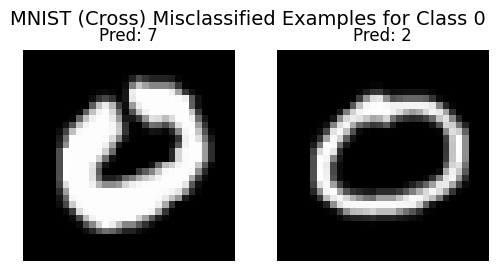

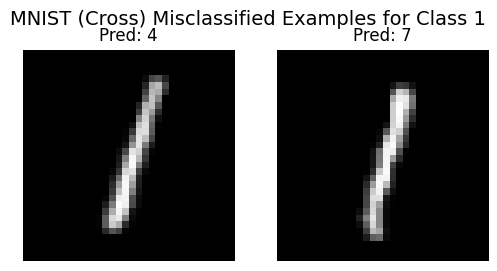

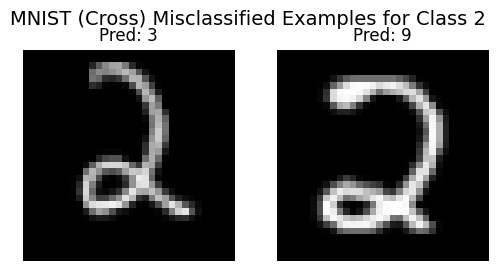

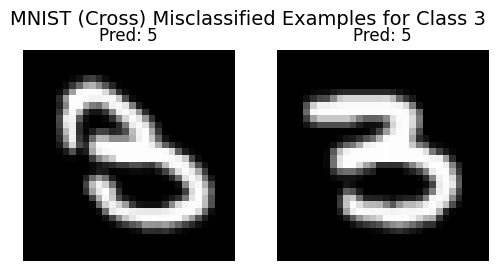

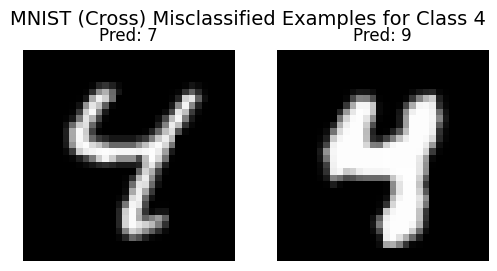

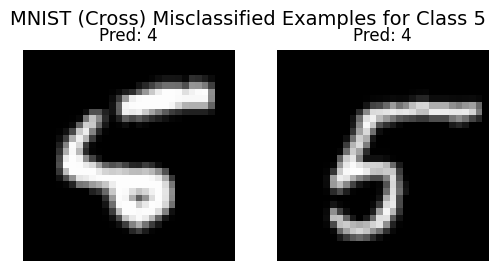

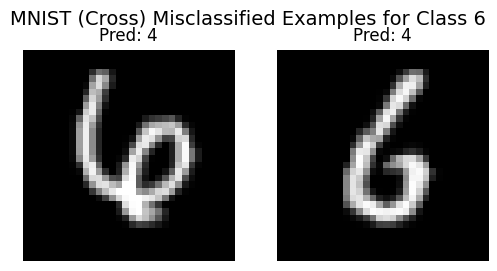

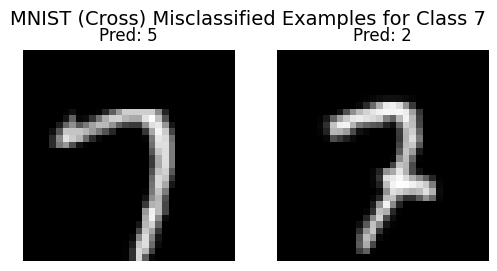

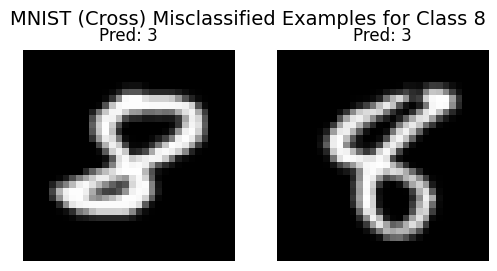

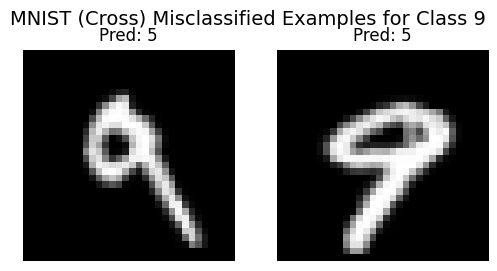

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


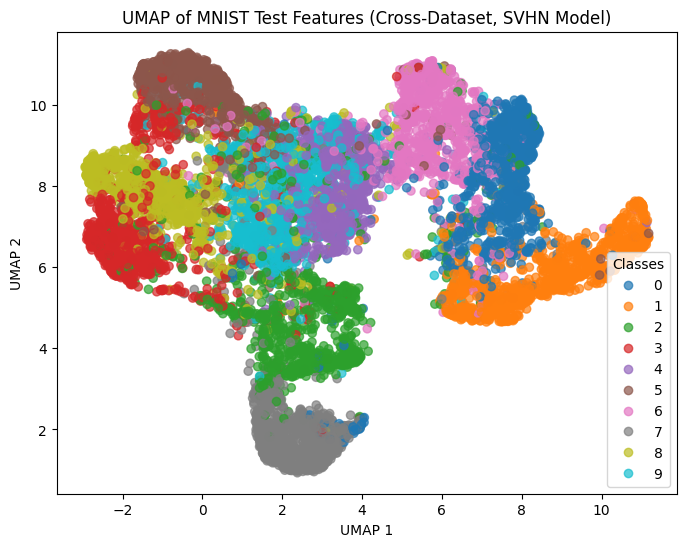

Classification Report for MNIST (Cross-Dataset Evaluation using SVHN Model):
              precision    recall  f1-score   support

           0     0.8462    0.5388    0.6584       980
           1     0.7866    0.7048    0.7435      1135
           2     0.5418    0.4021    0.4616      1032
           3     0.5375    0.8158    0.6481      1010
           4     0.3562    0.7088    0.4741       982
           5     0.6121    0.7623    0.6790       892
           6     0.6952    0.2547    0.3728       958
           7     0.6468    0.7714    0.7036      1028
           8     0.7791    0.5903    0.6717       974
           9     0.4794    0.3231    0.3860      1009

    accuracy                         0.5881     10000
   macro avg     0.6281    0.5872    0.5799     10000
weighted avg     0.6293    0.5881    0.5815     10000



In [11]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Check if mnist_test is defined; if not, load the MNIST test dataset.
try:
    mnist_test
except NameError:
    print("mnist_test is not defined. Loading MNIST test dataset...")
    mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

# ----------------------------------------------------------------
# Data Transformation: Convert MNIST (28x28, grayscale) to 32x32 RGB.
# ----------------------------------------------------------------
# We no longer call ToPILImage() in the transformation because the custom dataset will handle it.
mnist_to_svhn_transform = transforms.Compose([
    transforms.Resize((32, 32)),                      # Resize from 28x28 to 32x32
    transforms.Lambda(lambda img: img.convert("RGB")),  # Convert grayscale PIL image to RGB
    transforms.ToTensor()                             # Convert back to tensor (values scaled to [0, 1])
])

# Create a custom dataset that applies the above transformation on-the-fly.
class MNISTCrossDataset(torch.utils.data.Dataset):
    def __init__(self, original_dataset, transform):
        self.dataset = original_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        # Convert the MNIST tensor image (28x28) to a PIL Image.
        img = transforms.ToPILImage()(img)
        # Apply our transformation to get a 32x32 RGB image.
        img = self.transform(img)
        return img, label

# Create the cross-dataset MNIST test set using the custom dataset.
mnist_cross_dataset = MNISTCrossDataset(mnist_test, mnist_to_svhn_transform)
mnist_cross_loader = DataLoader(mnist_cross_dataset, batch_size=64, shuffle=False)

# ----------------------------------------------------------------
# Evaluation: Compute loss and metrics using the SVHN-trained model.
# ----------------------------------------------------------------
def evaluate_cross_dataset(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall, all_preds, all_labels

criterion = torch.nn.CrossEntropyLoss()
mnist_loss, mnist_acc, mnist_prec, mnist_rec, mnist_preds, mnist_labels = evaluate_cross_dataset(final_model_svhn, mnist_cross_loader, criterion, device)

print("\nCross-Dataset Evaluation (SVHN Model on MNIST Test Set):")
print(f"Loss: {mnist_loss:.4f}, Accuracy: {mnist_acc:.4f}, Precision: {mnist_prec:.4f}, Recall: {mnist_rec:.4f}")

# ----------------------------------------------------------------
# Misclassification Visualization: Display misclassified examples.
# ----------------------------------------------------------------
def visualize_misclassifications_cross(model, dataloader, device, dataset_name):
    model.eval()
    misclassified = {i: [] for i in range(10)}
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            for img, true_label, pred_label in zip(images, labels, preds):
                if true_label.item() != pred_label.item():
                    if len(misclassified[true_label.item()]) < 2:
                        misclassified[true_label.item()].append((img.cpu(), pred_label.item()))
            if all(len(misclassified[i]) >= 2 for i in range(10)):
                break

    for cls in range(10):
        examples = misclassified[cls]
        if examples:
            fig, axes = plt.subplots(1, len(examples), figsize=(3 * len(examples), 3))
            fig.suptitle(f'{dataset_name} Misclassified Examples for Class {cls}', fontsize=14)
            if len(examples) == 1:
                axes = [axes]
            for ax, (img, pred_label) in zip(axes, examples):
                ax.imshow(img.permute(1, 2, 0))  # Display the image (convert from CxHxW to HxWxC)
                ax.set_title(f"Pred: {pred_label}")
                ax.axis('off')
            plt.show()
        else:
            print(f"No misclassified examples found for class {cls} in {dataset_name}.")

print("\nMNIST Misclassifications (Cross-Dataset Evaluation using SVHN Model):")
visualize_misclassifications_cross(final_model_svhn, mnist_cross_loader, device, "MNIST (Cross)")

# ----------------------------------------------------------------
# UMAP Visualization: Reduce feature dimensions and visualize.
# ----------------------------------------------------------------
import umap

def extract_features_cross(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

mnist_features_cross, mnist_labels_cross = extract_features_cross(final_model_svhn, mnist_cross_loader, device)
umap_reducer = umap.UMAP(n_components=2, random_state=42)
mnist_embedded_cross = umap_reducer.fit_transform(mnist_features_cross)

plt.figure(figsize=(8,6))
scatter = plt.scatter(mnist_embedded_cross[:, 0], mnist_embedded_cross[:, 1], c=mnist_labels_cross, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("UMAP of MNIST Test Features (Cross-Dataset, SVHN Model)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

# ----------------------------------------------------------------
# Classification Report: Print detailed per-class performance.
# ----------------------------------------------------------------
print("Classification Report for MNIST (Cross-Dataset Evaluation using SVHN Model):")
print(classification_report(mnist_labels, mnist_preds, digits=4))

# **Step 7: UMAP Dimensionality Reduction for SVHN Features**

## Explanation

- **Feature Extraction:**  
  Extract feature representations from the final SVHN model’s fully connected layer using the SVHN test set.

- **UMAP Dimensionality Reduction:**  
  Apply UMAP to reduce these high-dimensional features to 2D.

- **Visualization:**  
  Create a scatter plot of the 2D UMAP embedding, with each point colored by its true label.

This process helps visualize the latent space learned by the model.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


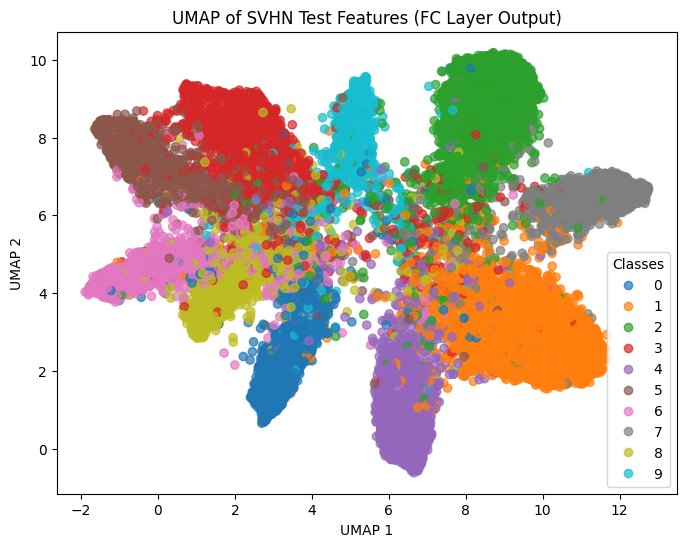

In [12]:
!pip install umap-learn -q

import umap

def extract_features(model, dataloader, device):
    model.eval()
    features = []
    labels = []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels.append(lbls.numpy())
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

svhn_features, svhn_labels = extract_features(final_model_svhn, final_test_loader, device)

umap_reducer = umap.UMAP(n_components=2, random_state=42)
svhn_embedded = umap_reducer.fit_transform(svhn_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(svhn_embedded[:, 0], svhn_embedded[:, 1], c=svhn_labels, cmap='tab10', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("UMAP of SVHN Test Features (FC Layer Output)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()


# **Step 8: Imbalanced Training & Analysis on SVHN (Classes 1 and 2)**

## Explanation

In this final section for SVHN, we simulate imbalanced training on only two classes (1 and 2) by testing three cases:

- **Case 1:** 50 samples of class 1 and 1000 samples of class 2.
- **Case 2:** 500 samples of class 1 and 1000 samples of class 2.
- **Case 3:** Use all available samples for classes 1 and 2.

### For Each Case

1. **Data Preparation:**
   - Filter the SVHN training set for classes 1 and 2.
   - Sample the desired number of examples for each class.
2. **Model Training:**
   - Train a CNN model on the imbalanced data for 50 epochs.
3. **Evaluation on SVHN:**
   - Filter the SVHN test set for classes 1 and 2.
   - Evaluate the model and print performance metrics.
4. **Latent Space Visualization:**
   - Extract features from the final fully connected layer.
   - Use UMAP to visualize the latent space with a scatter plot.
5. **Additional Evaluation on MNIST:**
   - Convert MNIST grayscale images to 3-channel RGB for compatibility.
   - Filter the MNIST test set for classes 1 and 2.
   - Evaluate the model on the transformed MNIST test set.

This analysis provides insights into the effects of class imbalance on model performance across different datasets.



Training SVHN Model - Case 1
Epoch 1/50 - Train Loss: 0.5806, Train Acc: 0.8962
Epoch 10/50 - Train Loss: 0.0284, Train Acc: 0.9905
Epoch 20/50 - Train Loss: 0.0053, Train Acc: 1.0000
Epoch 30/50 - Train Loss: 0.0019, Train Acc: 1.0000
Epoch 40/50 - Train Loss: 0.0014, Train Acc: 1.0000
Epoch 50/50 - Train Loss: 0.0006, Train Acc: 1.0000
SVHN Test Metrics (Classes 1 & 2): Loss: 0.9933, Acc: 0.7560, Prec: 0.8187, Rec: 0.7818


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


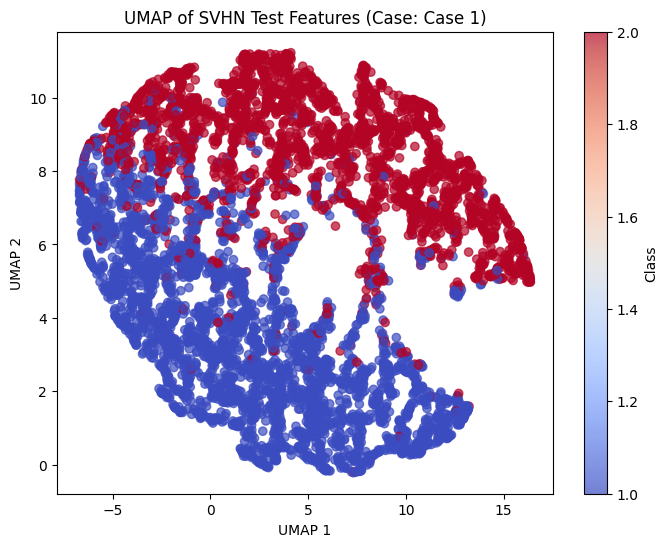


Training SVHN Model - Case 2
Epoch 1/50 - Train Loss: 0.8408, Train Acc: 0.6040
Epoch 10/50 - Train Loss: 0.0660, Train Acc: 0.9827
Epoch 20/50 - Train Loss: 0.0328, Train Acc: 0.9907
Epoch 30/50 - Train Loss: 0.0107, Train Acc: 0.9987
Epoch 40/50 - Train Loss: 0.0258, Train Acc: 0.9907
Epoch 50/50 - Train Loss: 0.0028, Train Acc: 1.0000
SVHN Test Metrics (Classes 1 & 2): Loss: 0.1968, Acc: 0.9509, Prec: 0.9489, Rec: 0.9528


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


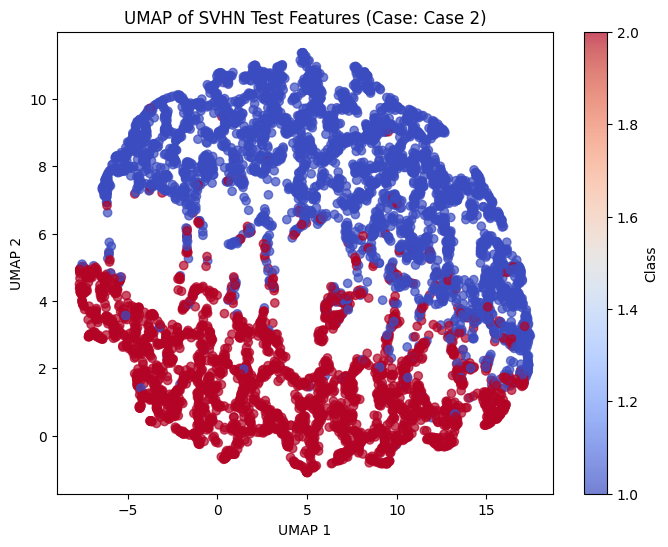


Training SVHN Model - Case 3
Epoch 1/50 - Train Loss: 0.2072, Train Acc: 0.9157
Epoch 10/50 - Train Loss: 0.0540, Train Acc: 0.9822
Epoch 20/50 - Train Loss: 0.0295, Train Acc: 0.9904
Epoch 30/50 - Train Loss: 0.0235, Train Acc: 0.9922
Epoch 40/50 - Train Loss: 0.0169, Train Acc: 0.9943
Epoch 50/50 - Train Loss: 0.0049, Train Acc: 0.9989
SVHN Test Metrics (Classes 1 & 2): Loss: 0.1520, Acc: 0.9770, Prec: 0.9766, Rec: 0.9768


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


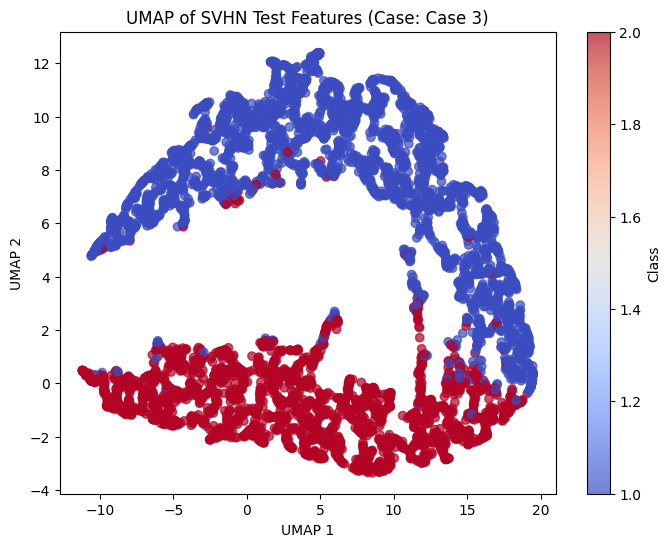


Summary of SVHN Imbalanced Training Results (Classes 1 & 2):
Case 1: {'loss': 0.9932673388501764, 'accuracy': 0.7560029828486204, 'precision': 0.8186980828631966, 'recall': 0.7818184231517498}
Case 2: {'loss': 0.1968481105579359, 'accuracy': 0.9509321401938852, 'precision': 0.9489492271952087, 'recall': 0.9528215612597435}
Case 3: {'loss': 0.15199452416956047, 'accuracy': 0.9770320656226696, 'precision': 0.9765610829103215, 'recall': 0.9768375141966112}


In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score, precision_score, recall_score
import umap

# Ensure reproducibility.
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# Assume svhn_train_split and svhn_test_split are already defined from the previous SVHN loading and splitting.
# If not, you should have something like:
# svhn_train = SVHNWrapper(torchvision.datasets.SVHN(root='./data', split='train', download=True, transform=transforms.ToTensor()))
# svhn_test  = SVHNWrapper(torchvision.datasets.SVHN(root='./data', split='test', download=True, transform=transforms.ToTensor()))
# svhn_full = ConcatDataset([svhn_train, svhn_test])
# svhn_train_split, svhn_val_split, svhn_test_split = split_dataset(svhn_full)

# -------------------------------------------------------------------
# Step 1: Filter SVHN dataset for classes 1 and 2
# -------------------------------------------------------------------

def filter_dataset(dataset, allowed_classes):
    filtered = []
    for img, label in dataset:
        if label in allowed_classes:
            filtered.append((img, label))
    return filtered

svhn_train_filtered = filter_dataset(svhn_train_split, [1, 2])
svhn_test_filtered = filter_dataset(svhn_test_split, [1, 2])

# Create a custom dataset wrapper for easier DataLoader usage.
class CustomDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

# Create DataLoader for SVHN test set (classes 1 & 2)
svhn_test_loader_12 = DataLoader(CustomDataset(svhn_test_filtered), batch_size=64, shuffle=False)

# -------------------------------------------------------------------
# Step 2: Define a helper function for sampling imbalanced data.
# -------------------------------------------------------------------
def sample_imbalanced(data, sample_counts):
    """
    Randomly sample a fixed number of examples per class.
    sample_counts: dict mapping class -> number of samples.
    """
    data_by_class = {cls: [] for cls in sample_counts.keys()}
    for item in data:
        img, label = item
        if label in data_by_class:
            data_by_class[label].append(item)
    sampled_data = []
    for cls, count in sample_counts.items():
        class_items = data_by_class[cls]
        random.shuffle(class_items)
        sampled_data.extend(class_items[:count])
    random.shuffle(sampled_data)
    return sampled_data

# -------------------------------------------------------------------
# Step 3: Define the SVHN model (improved version) for imbalanced training.
# -------------------------------------------------------------------
class SimpleCNN_SVHN_Improved(nn.Module):
    def __init__(self, in_channels, img_size, activation=nn.ReLU()):
        """
        in_channels: Number of input channels (3 for SVHN)
        img_size: Input image size (32 for SVHN)
        activation: Activation function
        """
        super(SimpleCNN_SVHN_Improved, self).__init__()
        self.activation = activation
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool  = nn.MaxPool2d(2, 2)
        final_size = img_size // 4  # For 32x32, final_size = 8
        self.fc    = nn.Linear(64 * final_size * final_size, 10)

    def forward(self, x):
        x = self.pool(self.activation(self.bn1(self.conv1(x))))
        x = self.pool(self.activation(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# -------------------------------------------------------------------
# Step 4: Training and Evaluation functions (reuse from earlier)
# -------------------------------------------------------------------
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    epoch_recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_precision, epoch_recall

# -------------------------------------------------------------------
# Step 5: Imbalanced Training Experiments for SVHN (Classes 1 and 2)
# -------------------------------------------------------------------
imbalanced_cases = {
    "Case 1": {1: 50, 2: 1000},
    "Case 2": {1: 500, 2: 1000},
    "Case 3": "Full"  # Use all available samples for classes 1 and 2.
}

epochs_imbalanced = 50
learning_rate_imbalanced = 0.001
criterion = nn.CrossEntropyLoss()

results_svhn_imbalanced = {}

for case, counts in imbalanced_cases.items():
    print(f"\n{'='*20}\nTraining SVHN Model - {case}\n{'='*20}")
    if counts == "Full":
        imbalanced_train_data = svhn_train_filtered
    else:
        imbalanced_train_data = sample_imbalanced(svhn_train_filtered, counts)

    train_loader = DataLoader(CustomDataset(imbalanced_train_data), batch_size=64, shuffle=True)

    # Initialize a fresh model for SVHN imbalanced training.
    model_imbalanced = SimpleCNN_SVHN_Improved(in_channels=3, img_size=32, activation=nn.ReLU()).to(device)
    optimizer_imbalanced = optim.Adam(model_imbalanced.parameters(), lr=learning_rate_imbalanced)

    # Train for specified epochs.
    for epoch in range(1, epochs_imbalanced+1):
        train_loss, train_acc = train_epoch(model_imbalanced, train_loader, optimizer_imbalanced, criterion, device)
        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs_imbalanced} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

    # Evaluate on the SVHN test set (filtered for classes 1 and 2)
    svhn_loss, svhn_acc, svhn_prec, svhn_rec = evaluate(model_imbalanced, svhn_test_loader_12, criterion, device)[:4]
    print(f"SVHN Test Metrics (Classes 1 & 2): Loss: {svhn_loss:.4f}, Acc: {svhn_acc:.4f}, Prec: {svhn_prec:.4f}, Rec: {svhn_rec:.4f}")

    # -------------------------------------------------------------------
    # Step 6: UMAP Visualization of Features for Imbalanced Training Case
    # -------------------------------------------------------------------
    def extract_features(model, dataloader, device):
        model.eval()
        features = []
        labels = []
        with torch.no_grad():
            for images, lbls in dataloader:
                images = images.to(device)
                outputs = model(images)
                features.append(outputs.cpu().numpy())
                labels.append(lbls.numpy())
        features = np.concatenate(features, axis=0)
        labels = np.concatenate(labels, axis=0)
        return features, labels

    test_features, test_labels = extract_features(model_imbalanced, svhn_test_loader_12, device)
    umap_reducer = umap.UMAP(n_components=2, random_state=42)
    test_embedded = umap_reducer.fit_transform(test_features)

    plt.figure(figsize=(8,6))
    sc = plt.scatter(test_embedded[:,0], test_embedded[:,1], c=test_labels, cmap='coolwarm', alpha=0.7)
    plt.title(f"UMAP of SVHN Test Features (Case: {case})")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.colorbar(sc, label="Class")
    plt.show()

    results_svhn_imbalanced[case] = {
        "loss": svhn_loss,
        "accuracy": svhn_acc,
        "precision": svhn_prec,
        "recall": svhn_rec
    }

print("\nSummary of SVHN Imbalanced Training Results (Classes 1 & 2):")
for case, metrics in results_svhn_imbalanced.items():
    print(f"{case}: {metrics}")